Să presupunem că investigăm o boală (B), care afectează doar un procent din populaţie (P(B) = 0.01). Avem un test de
diagnosticare pentru această boală, care are următoarele caracteristici: \
● Sensibilitate (probabilitatea ca testul să fie pozitiv dacă persoana este bolnavă): P(Test = Pozitiv∣B) = 0.95 \
● Specificitate (probabilitatea ca testul să fie negativ dacă persoana nu este bolnavă): P(Test = Negativ∣¬B) = 0.90 \
a) Dacă o persoană este testată şi rezultatul este pozitiv, care este probabilitatea ca aceasta să fie efectiv bolnavă? \
Cum explicaţí rezultatul?



Voi nota cu **T** evenimentul "Test = Pozitiv"
$$
\begin{align*}
P(B) &= 0.01 \Rightarrow P(\lnot B) = 0.99 \\
P(T | B) &= 0.95 \Rightarrow P(\lnot T | B) = 0.05 \\
P(\lnot T | \lnot B) &= 0.90 \Rightarrow P( T | \lnot B) = 0.10 \\
P(B \cap T) &= P(T | B) * P(B) = 0.95 * 0.01 = 0.0095 \\
P(B \cap \lnot T) &= P(\lnot T | B) * P(B) = 0.05 * 0.01 = 0.0005 \\
P(\lnot B \cap T) &= P(T | \lnot B) * P(\lnot B) = 0.10 * 0.99 = 0.099 \\
P(\lnot B \cap \lnot T) &= P(\lnot T | \lnot B) * P(\lnot B) = 0.90 * 0.99 = 0.891 \\
P(T) &= P(B \cap T) + P(\lnot B \cap T) = 0.0095 + 0.099 = 0.1085 \\
P(\lnot T) &= P(B \cap \lnot T) + P(\lnot B \cap \lnot T) = 0.0005 + 0.891 = 0.8915 \\
P(B | T) &= \frac{P(B \cap T)}{P(T)} = \frac{0.0095}{0.1085} \approx 0.0876 \\
P(\lnot B | T) &= \frac{P(\lnot B \cap T)}{P(T)} = \frac{0.099}{0.1085} \approx 0.9124 \\
P(B | \lnot T) &= \frac{P(B \cap \lnot T)}{P(\lnot T)} = \frac{0.0005}{0.8915} \approx 0.0006 \\
P(\lnot B | \lnot T) &= \frac{P(\lnot B \cap \lnot T)}{P(\lnot T)} = \frac{0.891}{0.8915} \approx 0.9994 \\
\end{align*}
$$

Testul este insuficient de precis (specific) pentru rata mică de incidență a bolii. Ex. din 2000 de persoane, 19 (True positive) + 180 (False negative) ar primi rezultat pozitiv la test, deși doar 20 sunt bolnave.

b) Modelaţi în Python probabilitatea de mai sus şi comparaţi cu cea obţinută teoretic la punctul anterior.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

def get_person(sensibility : float, specificity : float, sickness_rate : float) :

    sick = rng.binomial(1, sickness_rate)
    if (sick == 1) :
        test = rng.binomial(1, sensibility)
    else :
        test = rng.binomial(1, 1 - specificity)
    return (sick, test)

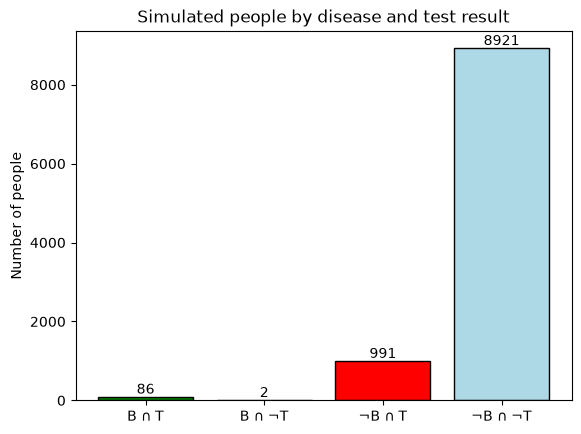

P(B | T) ≈ 0.07985143918291551


In [22]:
people = [get_person(0.95, 0.90, 0.01) for i in range(10000)]

# (sick, test) for each of the 4 cases
cases = [(1, 1), (1, 0), (0, 1), (0, 0)]
labels = ['B ∩ T', 'B ∩ ¬T', '¬B ∩ T', '¬B ∩ ¬T']
counts = [people.count(c) for c in cases]

bars = plt.bar(labels, counts, color=['green', 'orange', 'red', 'lightblue'], edgecolor='black')
plt.bar_label(bars)
plt.title('Simulated people by disease and test result')
plt.ylabel('Number of people')
plt.show()

print("P(B | T) ≈", counts[0] / (counts[0] + counts[2]))

Este aceași probabilitate.

c) Care ar trebui să fie specificitatea minimă pentru ca probabilitatea de mai sus să ajungă la 50%? \

$P(B \cap T) = P(T | B) * P(B)$, putem modifica doar $P(\lnot T | \lnot B)$, deci $P(B \cap T)$ va fi considerat constant \\
$$
P(B | T) = \frac{P(B \cap T)}{P(T)} = \frac{0.0095}{ 0.0095 + P(\lnot B \cap T)} = \frac{0.0095}{ 0.0095 + P(T | \lnot B) * P(\lnot B)} = \frac{0.0095}{ 0.0095 + P(T | \lnot B) * 0.99} \\
\frac{0.0095}{ 0.0095 + P(T | \lnot B) * 0.99} \geq 0.5 \iff 0.0095 \geq (0.0095 + P(T | \lnot B) * 0.99) * 0.5\\ 
\iff 0.0095 \geq 0.00475 + P(T | \lnot B) * 0.495 \\
\iff 0.00475 \geq P(T | \lnot B) * 0.495 \\
\iff P(T | \lnot B) \leq \frac{0.00475}{0.495} = \frac{0.0095}{0.99} \approx 0.009596 \\
P(\lnot T | \lnot B) = 1 - P(T | \lnot B) \geq 1 - 0.009596 = 0.990404
$$

Specificitatea minimă trebuie să fie $\approx 0.9904$, adică aproximativ 99.04%.